## ML Assignment 2

In [145]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

In [146]:
#Extract the data
eth_file_path = "https://raw.githubusercontent.com/JovitaBer/ML_2026_Practice/main/assignment2/_eth_dkk.csv"
novo_file_path = "https://raw.githubusercontent.com/JovitaBer/ML_2026_Practice/main/assignment2/_XCSE_NOVO-1.csv"

df_eth = pd.read_csv(eth_file_path, sep=";")
df_novo = pd.read_csv(novo_file_path)

In [147]:
# Define colors
NOVO_COL = "#1f77b4"  # color for Novo Nordisk
ETH_COL = "#ff7f0e"   # color for Ethereum

### **1. DATA CLEANING**

In [148]:
#function for parsing the billion and trillion suffixes
def parse_suffix(val):
    val = str(val).replace(",", "")
    if "B" in val:
        return int(float(val.replace("B", "")) * 1_000_000_000)
    elif "T" in val:
        return int(float(val.replace("T", "")) * 1_000_000_000_000)
    else:
        return int(float(val))

In [149]:
#rename columns to have consistency
#from danish to english
df_eth.rename(columns={
    "Dato"         : "date",
    "Åbning"       : "open",
    "Høj"          : "high",
    "Lav"          : "low",
    "Luk"          : "close",
    "Volumen"      : "volume",
    "Markedsværdi" : "market_cap",
    "Ændring, %"   : "change_pct"
}, inplace=True)

df_novo.rename(columns={
    "Date"      : "date",
    "Open"      : "open",
    "High"      : "high",
    "Low"       :  "low",
    "Close"     :"close",
    "Volume"    :"volume"}, inplace=True)

#fix date format
df_novo["date"] = pd.to_datetime(df_novo["date"], format="%m/%d/%Y")
df_eth["date"] = pd.to_datetime(df_eth["date"])

#sort values by date in ascending order
df_novo = df_novo.sort_values('date')
df_eth = df_eth.sort_values('date')

#reset index after sorting
df_novo = df_novo.reset_index(drop=True)
df_eth = df_eth.reset_index(drop=True)

#fix number formatting for price columns in novo dataset
cols = ["open", "high", "low", "close"]

for col in cols:
    df_novo[col] = (df_novo[col].astype(str)
                                .str.replace(".", "", regex=False)   # remove thousands separator
                                .str.replace(",", ".", regex=False)  # replace decimal separator
                                .astype(float))
# fix volume (remove commas) for novo dataset
df_novo["volume"] = df_novo["volume"].astype(str).str.replace(",", "", regex=False).astype(float)

#fix volume, market_cap formatting for eth dataset (remove B/T suffixes)
df_eth["volume"] = df_eth["volume"].apply(parse_suffix)
df_eth["market_cap"] = df_eth["market_cap"].apply(parse_suffix)



In [150]:
df_eth.head(5)

,date,open,high,low,close,volume,market_cap,change_pct
0,2025-03-01,16081.11,16394.10,15399.37,15935.94,132889999999,1920000000000,-0.99
1,2025-03-02,15936.01,18330.51,15610.02,18097.15,111540000000,2180000000000,13.56
2,2025-03-03,17932.04,17970.78,14939.64,15303.53,294590000000,1850000000000,-15.44
3,2025-03-04,15122.44,15635.15,14025.95,15280.70,244050000000,1840000000000,-0.15
4,2025-03-05,15010.06,15715.18,14896.21,15494.54,185410000000,1870000000000,1.40


In [151]:
df_novo.head(5)

,date,open,high,low,close,volume
0,2025-02-27,63000.0,64580.0,62830.0,64180.0,2974061.0
1,2025-02-28,64100.0,64820.0,63120.0,64450.0,7285161.0
2,2025-03-03,65000.0,65120.0,63620.0,63910.0,2242871.0
3,2025-03-04,63460.0,64240.0,61620.0,61620.0,3058878.0
4,2025-03-05,61610.0,64940.0,61400.0,63150.0,3515981.0


## **EDA**

For the price analysis, the **closing price** is selected for the main focus of the EDA part. It produces a consistent, comparable time series. The prices throghout the day are noisy — the high and low are essentially accidents of timing (a single large order can spike the price ). The close is more stable and comparable across days.
Also, from the financial point of view, close price is what investors actually transact at (or near). Most institutional trades, fund valuations, and portfolio rebalancing happen at or around the close. It's also the price used to calculate official index values, ETF net asset values, and most financial benchmarks [1]. This makes it the most economically meaningful reference point.
Thus, when focusing on the main metric: returns on investment over time, the time-series should be more stable.

[1] https://www.investopedia.com/terms/c/closingprice.asp  

#### 1.1. Check Missing Values

In [152]:
print("Missing values for novo:", df_eth.isna().sum())
print("Missing values for etherium:", df_novo.isna().sum())

Missing values for novo: date          0
open          0
high          0
low           0
close         0
volume        0
market_cap    0
change_pct    0
dtype: int64
Missing values for etherium: date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


#### 1.2. Closing Price EDA (TO DO: relate the findings with the assignment questions):
- Total Price Comparison
- Normalized Price Comparison
- Distribution of Daily Returns
- Histogram of Daily Return
- Standard Deviation of Returns (Volatility)
- Static Calculator of ROI

In [153]:
summary = pd.DataFrame({
    "Novo Nordisk": df_novo["close"].describe(),
    "Ethereum (DKK)": df_eth["close"].describe(),
}).round(2)
summary

,Novo Nordisk,Ethereum (DKK)
count,250.00,366.00
mean,39047.30,19307.10
std,7997.06,5617.08
min,23790.00,10040.85
25%,32262.50,14851.38
50%,37330.00,18775.78
75%,44147.50,24164.73
max,64450.00,30768.21


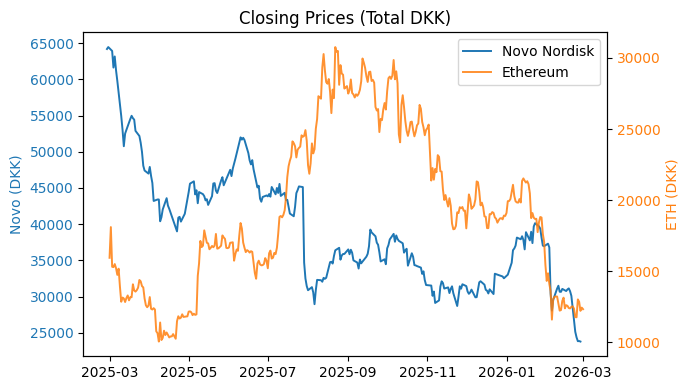

In [154]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1r = ax1.twinx()

ax1.plot(df_novo["date"], df_novo["close"], color=NOVO_COL, lw=1.4, label="Novo Nordisk")
ax1r.plot(df_eth["date"], df_eth["close"], color=ETH_COL, lw=1.4, alpha=0.85, label="Ethereum")

ax1.set_ylabel("Novo (DKK)", color=NOVO_COL)
ax1r.set_ylabel("ETH (DKK)", color=ETH_COL)
ax1.tick_params(axis="y", labelcolor=NOVO_COL)
ax1r.tick_params(axis="y", labelcolor=ETH_COL)
ax1.set_title("Closing Prices (Total DKK)")

lines = ax1.get_lines() + ax1r.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="upper right")

plt.tight_layout()
plt.show()

Normalized Performance (Base = 100) plot is commonly used in finance because it allows to compare assets with very different price levels. Instead of comparing prices directly, we scale both assets to start at 100 and observe how they grow over time. The normalized performance chart illustrates the relative growth of each investment over time and highlights differences in volatility and long-term returns.
This means that:
- Both assets start at 100
    - E.g., if Ethereum ends at 350, it means it increased 250%
    - E.g., ff Novo Nordisk ends at 180, it increased 80%

This visually shows which investment grew faster.

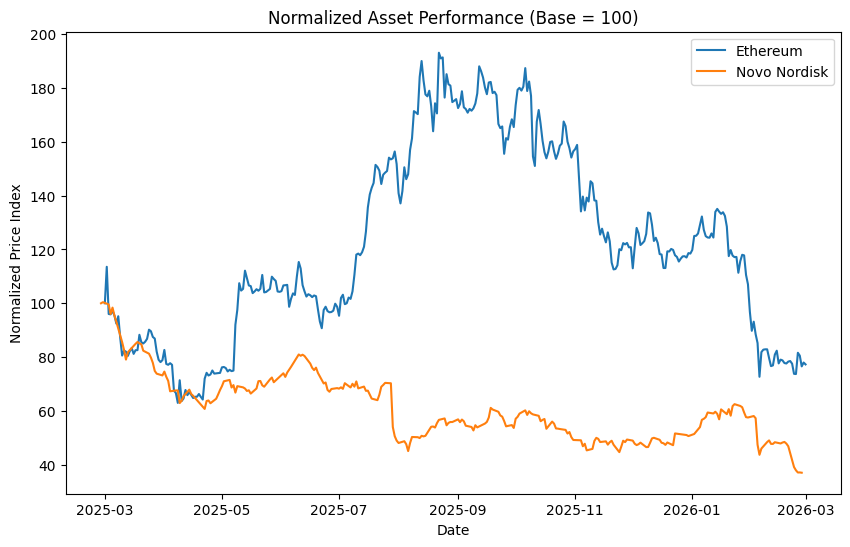

In [155]:
#normalized price comparison
# Normalize prices
df_eth['normalized'] = (df_eth['close'] / df_eth['close'].iloc[0]) * 100
df_novo['normalized'] = (df_novo['close'] / df_novo['close'].iloc[0]) * 100

plt.figure(figsize=(10,6))

plt.plot(df_eth['date'], df_eth['normalized'], label='Ethereum')
plt.plot(df_novo['date'], df_novo['normalized'], label='Novo Nordisk')

plt.title("Normalized Asset Performance (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Normalized Price Index")
plt.legend()

plt.show()

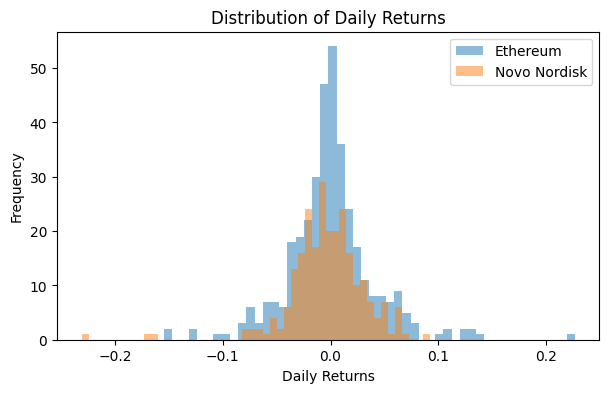

In [156]:
df_eth['return'] = df_eth['close'].pct_change()
df_novo['return'] = df_novo['close'].pct_change()

plt.figure(figsize=(7,4))

plt.hist(df_eth['return'].dropna(), bins=50, alpha=0.5, label='Ethereum')
plt.hist(df_novo['return'].dropna(), bins=50, alpha=0.5, label='Novo Nordisk')

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Returns")
plt.ylabel("Frequency")
plt.legend()

plt.show()

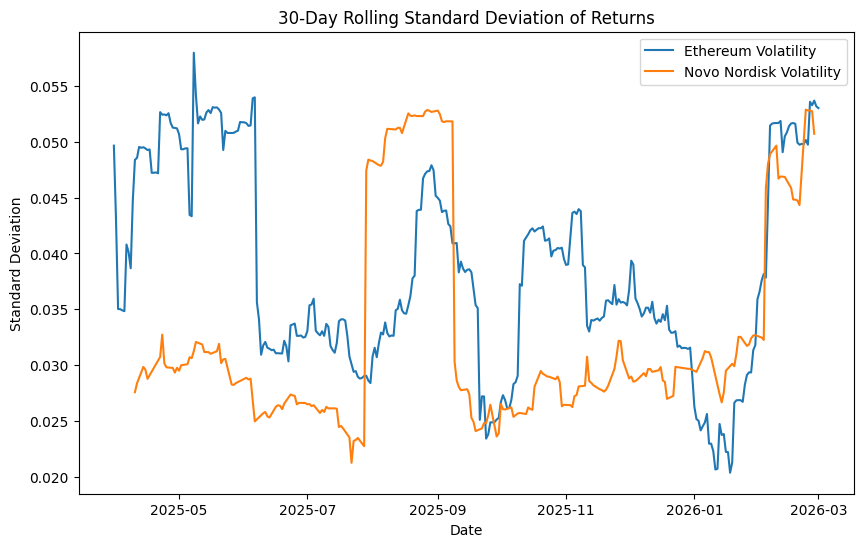

In [157]:
#during the time, show the volatility of the two assets by calculating the rolling standard deviation of daily returns
window = 30

df_eth['volatility'] = df_eth['return'].rolling(window).std()
df_novo['volatility'] = df_novo['return'].rolling(window).std()

plt.figure(figsize=(10,6))

plt.plot(df_eth['date'], df_eth['volatility'], label='Ethereum Volatility')
plt.plot(df_novo['date'], df_novo['volatility'], label='Novo Nordisk Volatility')

plt.title('30-Day Rolling Standard Deviation of Returns')
plt.xlabel('Date')
plt.ylabel('Standard Deviation')
plt.legend()

plt.show()

The standard deviation of returns was used as a measure of investment risk. Ethereum exhibits significantly higher volatility compared to Novo Nordisk stock. The rolling 30-day volatility plot shows more frequent spikes in Ethereum returns, indicating substantial short-term price fluctuations. In contrast, Novo Nordisk demonstrates a more stable volatility pattern, suggesting lower investment risk. However, we also see two periods with large volatility for Novo Nordisk assets (before September and 2025 and 2026 March)

#### 1.3 Calculate ROI (simplified version: buy at first available day; sell at last available day)

In [158]:
capital = 250_000  # DKK

for name, data in [("Novo Nordisk", df_novo), ("Ethereum", df_eth)]:
    p_start = data["close"].iloc[0]
    p_end   = data["close"].iloc[-1]
    p_start_date = data["date"].iloc[0].strftime("%Y-%m-%d")
    p_end_date   = data["date"].iloc[-1].strftime("%Y-%m-%d")
    units   = capital / p_start
    val_end = units * p_end
    roi     = (val_end - capital) / capital * 100
    print(f"\n{name}")
    print(f"  Buy at date: {p_start_date}")
    print(f"  Buy at : DKK {p_start:>10,.2f}")
    print(f"  Sell at date: {p_end_date}")
    print(f"  Sell at  : DKK {p_end:>10,.2f}")
    print(f"  End value: DKK {val_end:>10,.2f}")
    print(f"  RoI      : {roi:>10.2f}%")


Novo Nordisk
  Buy at date: 2025-02-27
  Buy at : DKK  64,180.00
  Sell at date: 2026-02-27
  Sell at  : DKK  23,790.00
  End value: DKK  92,669.06
  RoI      :     -62.93%

Ethereum
  Buy at date: 2025-03-01
  Buy at : DKK  15,935.94
  Sell at date: 2026-03-01
  Sell at  : DKK  12,319.04
  End value: DKK 193,258.76
  RoI      :     -22.70%


#### 1.4. Detect Anomalies
For anomalies detection the price changes are used instead of total price.

##### Apply **Isolation Forest** for anomaly detection


In [159]:
df_eth['log_ret']  = np.log(df_eth['close']  / df_eth['close'].shift(1))
df_novo['log_ret'] = np.log(df_novo['close'] / df_novo['close'].shift(1))

model_eth  = IsolationForest(contamination=0.01, random_state=42)
model_novo = IsolationForest(contamination=0.01, random_state=42)

df_eth  = df_eth.dropna(subset=['log_ret'])
df_novo = df_novo.dropna(subset=['log_ret'])

df_eth['anomaly']  = model_eth.fit_predict(df_eth[['log_ret']])
df_novo['anomaly'] = model_novo.fit_predict(df_novo[['log_ret']])

# -1 = anomaly,  +1 = normal
df_eth_anomalies  = df_eth[df_eth['anomaly'] == -1]
df_novo_anomalies = df_novo[df_novo['anomaly'] == -1]

print(f"ETH anomalies detected  : {len(df_eth_anomalies)}")
print(f"Novo anomalies detected : {len(df_novo_anomalies)}")

ETH anomalies detected  : 4
Novo anomalies detected : 3


/tmp/ipykernel_1915/1280220282.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eth['anomaly']  = model_eth.fit_predict(df_eth[['log_ret']])


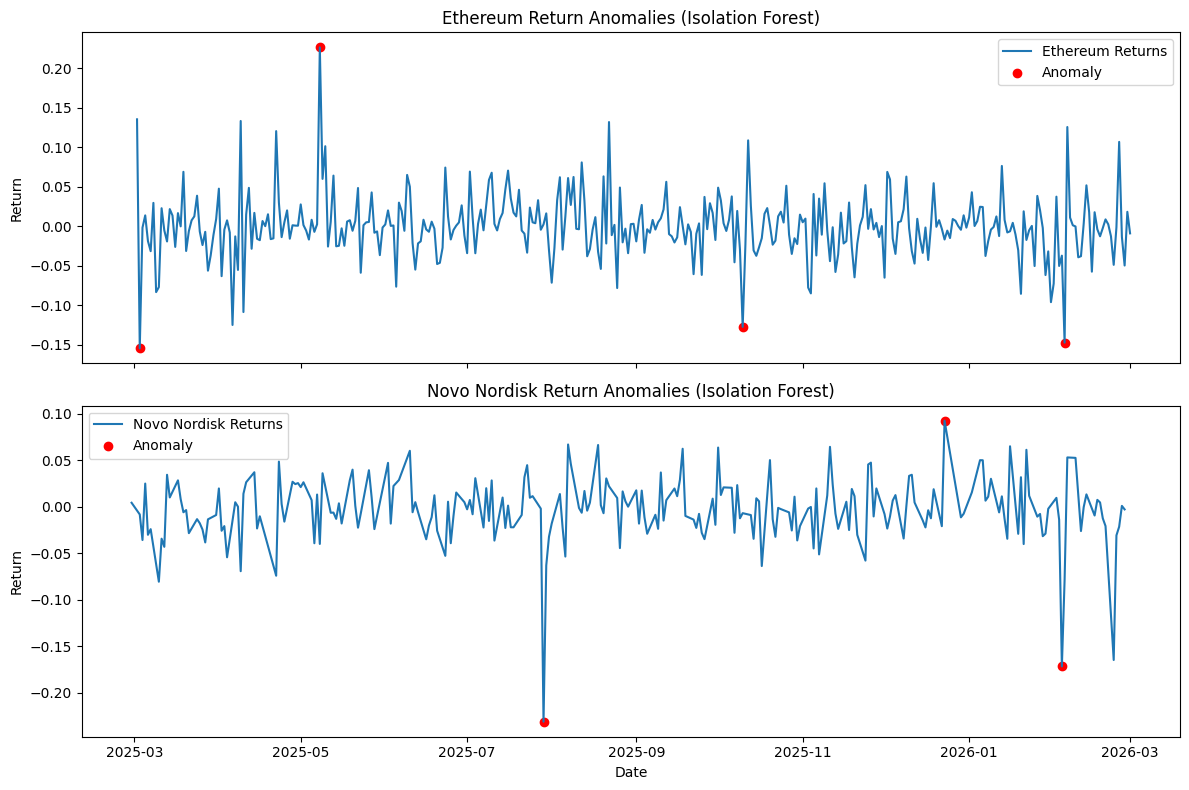

In [160]:
fig, ax = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# --- Ethereum plot (top) ---
ax[0].plot(df_eth['date'], df_eth['return'], label='Ethereum Returns')
ax[0].scatter(df_eth_anomalies['date'], df_eth_anomalies['return'],
              color='red', label='Anomaly')
ax[0].set_title("Ethereum Return Anomalies (Isolation Forest)")
ax[0].set_ylabel("Return")
ax[0].legend()

# --- Novo Nordisk plot (bottom) ---
ax[1].plot(df_novo['date'], df_novo['return'], label='Novo Nordisk Returns')
ax[1].scatter(df_novo_anomalies['date'], df_novo_anomalies['return'],
              color='red', label='Anomaly')
ax[1].set_title("Novo Nordisk Return Anomalies (Isolation Forest)")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Return")
ax[1].legend()

plt.tight_layout()
plt.show()

In [161]:
# risk-adjusted comparison

risk = pd.DataFrame({
    "Asset": ["Ethereum", "Novo Nordisk"],
    "Average Return (%)": [df_eth["return"].mean()*100, df_novo["return"].mean()*100],
    "Volatility (%)": [df_eth["return"].std()*100, df_novo["return"].std()*100]
})

risk = risk.round(3)

risk

,Asset,Average Return (%),Volatility (%)
0,Ethereum,0.012,4.087
1,Novo Nordisk,-0.332,3.543


Ethereum: 0.0121% average daily return

Novo Nordisk: -0.332% average daily return

Ethereum slightly gained value on average per day while Novo Nordisk lost value on average per day in your dataset period

Ethereum: 4.09% daily volatility

Novo Nordisk: 3.54% daily volatility

Ethereum price moves more aggressively while Novo Nordisk is slightly more stable

Overall, Ethereum gives better returns BUT at a higher risk

# 2. Capital Allocation Strategy:

How should the DKK 250,000 be allocated? Should you adopt a pure
strategy (100% allocation to one asset) or a hybrid strategy (e.g., X% in cryptocurrency and Y% in
stock)? What is the appropriate investment horizon (short-term vs. long-term; months vs. years)?

In [162]:
def analyze_allocation_roi2(capital, df_novo, df_eth, risk_profile='balanced', horizon='long-term'):
    """
    Parameters:
    - capital: float, initial capital in DKK.
    - df_novo, df_eth: DataFrames with columns 'date' and 'close'.
    - risk_profile: str, one of 'conservative', 'balanced', 'aggressive'.
    - horizon: str, 'short-term' (last 4 months) or 'long-term' (full data).

    Returns:
    - Prints allocation recommendation and performance metrics.
    """
    # Ensure data is sorted by date
    df_novo = df_novo.sort_values('date').copy()
    df_eth = df_eth.sort_values('date').copy()

    # Align dates using common dates
    common_dates = pd.merge(df_novo[['date']], df_eth[['date']], on='date', how='inner')
    df_novo = df_novo[df_novo['date'].isin(common_dates['date'])].copy()
    df_eth = df_eth[df_eth['date'].isin(common_dates['date'])].copy()

    # Filter by horizon
    if horizon == 'short-term':
        # Use last 4 months of data
        end_date = df_novo['date'].max()
        start_date = end_date - timedelta(days=120)
        df_novo = df_novo[df_novo['date'] >= start_date].copy()
        df_eth = df_eth[df_eth['date'] >= start_date].copy()
        print(f"\n--- Short-term horizon (last 4 months) ---")
    else:
        print(f"\n--- Long-term horizon (full data) ---")

    # Number of trading days in the period
    n_days = len(df_novo)

    # Compute daily returns
    df_novo['daily_return'] = df_novo['close'].pct_change()
    df_eth['daily_return'] = df_eth['close'].pct_change()

    # Drop NaN after pct_change
    returns = pd.DataFrame({
        'Novo': df_novo['daily_return'],
        'Ethereum': df_eth['daily_return']
    }).dropna()

    # Total period ROI (buy & hold)
    p_start_novo = df_novo['close'].iloc[0]
    p_end_novo   = df_novo['close'].iloc[-1]
    roi_novo = (p_end_novo / p_start_novo - 1) * 100

    p_start_eth = df_eth['close'].iloc[0]
    p_end_eth   = df_eth['close'].iloc[-1]
    roi_eth = (p_end_eth / p_start_eth - 1) * 100

    # Total volatility over the period (standard deviation of daily returns * sqrt(n_days))
    # Using the already trimmed returns (no NaN) for std calculation
    total_vol_novo = returns['Novo'].std() * np.sqrt(n_days) * 100      # in percent
    total_vol_eth  = returns['Ethereum'].std() * np.sqrt(n_days) * 100  # in percent
    correlation = returns['Novo'].corr(returns['Ethereum'])

    print(f"\nAsset Characteristics (over the whole period):")
    print(f"Novo Nordisk: Total ROI = {roi_novo:.2f}%, Total Volatility = {total_vol_novo:.2f}%")
    print(f"Ethereum:     Total ROI = {roi_eth:.2f}%, Total Volatility = {total_vol_eth:.2f}%")
    print(f"Correlation: {correlation:.4f}")

    # Pure strategies, showing detailed buy/sell info
    print(f"\nPure Strategies (buy & hold over selected period):")
    print(f"Novo Nordisk:")
    print(f"  Buy at {df_novo['date'].iloc[0].strftime('%Y-%m-%d')}: DKK {p_start_novo:>10,.2f}")
    print(f"  Sell at {df_novo['date'].iloc[-1].strftime('%Y-%m-%d')}: DKK {p_end_novo:>10,.2f}")
    val_end_novo = capital * (1 + roi_novo/100)
    print(f"  End value: DKK {val_end_novo:>10,.2f} | ROI: {roi_novo:>6.2f}%")
    print(f"Ethereum:")
    print(f"  Buy at {df_eth['date'].iloc[0].strftime('%Y-%m-%d')}: DKK {p_start_eth:>10,.2f}")
    print(f"  Sell at {df_eth['date'].iloc[-1].strftime('%Y-%m-%d')}: DKK {p_end_eth:>10,.2f}")
    val_end_eth = capital * (1 + roi_eth/100)
    print(f"  End value: DKK {val_end_eth:>10,.2f} | ROI: {roi_eth:>6.2f}%")

    # Hybrid portfolios: varying weights (w_novo from 0 to 1)
    weights_novo = np.linspace(0, 1, 11)
    results = []
    for w in weights_novo:
        w_eth = 1 - w
        port_roi = w * roi_novo + w_eth * roi_eth   # linear because buy-and-hold without rebalancing

        # Portfolio total volatility
        port_vol = np.sqrt(w**2 * total_vol_novo**2 + w_eth**2 * total_vol_eth**2 +
                           2 * w * w_eth * total_vol_novo * total_vol_eth * correlation)
        # Sharpe ratio (assuming risk-free rate = 0)
        sharpe = port_roi / port_vol if port_vol > 0 else np.nan

        results.append({
            'w_novo': w,
            'w_eth': w_eth,
            'roi': port_roi,
            'vol': port_vol,
            'sharpe': sharpe
        })

    df_port = pd.DataFrame(results)

    # Find optimal portfolios
    max_sharpe_idx = df_port['sharpe'].idxmax()
    min_vol_idx = df_port['vol'].idxmin()

    print(f"\n--- Portfolio Optimization ---")
    print(f"Minimum Volatility Portfolio:")
    print(f"  Novo: {df_port.loc[min_vol_idx, 'w_novo']*100:.1f}%, Ethereum: {df_port.loc[min_vol_idx, 'w_eth']*100:.1f}%")
    print(f"  Total ROI: {df_port.loc[min_vol_idx, 'roi']:.2f}%, Total Volatility: {df_port.loc[min_vol_idx, 'vol']:.2f}%")
    print(f"  Sharpe: {df_port.loc[min_vol_idx, 'sharpe']:.3f}")
    print(f"\nMaximum Sharpe (Tangency) Portfolio:")
    print(f"  Novo: {df_port.loc[max_sharpe_idx, 'w_novo']*100:.1f}%, Ethereum: {df_port.loc[max_sharpe_idx, 'w_eth']*100:.1f}%")
    print(f"  Total ROI: {df_port.loc[max_sharpe_idx, 'roi']:.2f}%, Total Volatility: {df_port.loc[max_sharpe_idx, 'vol']:.2f}%")
    print(f"  Sharpe: {df_port.loc[max_sharpe_idx, 'sharpe']:.3f}")

    # Risk-profile based recommendation
    if risk_profile == 'conservative':
        # Lowest volatility
        rec_idx = min_vol_idx
    elif risk_profile == 'aggressive':
        # Highest ROI (typically 100% of the asset with higher ROI)
        rec_idx = df_port['roi'].idxmax()
    else:  # 'balanced'
        # average the weights of the two optimal portfolios
        w_min = df_port.loc[min_vol_idx, 'w_novo']
        w_max = df_port.loc[max_sharpe_idx, 'w_novo']
        target_novo = (w_min + w_max) / 2
        # find the portfolio closest to this target
        rec_idx = (df_port['w_novo'] - target_novo).abs().idxmin()

    w_novo_rec = df_port.loc[rec_idx, 'w_novo']
    w_eth_rec = df_port.loc[rec_idx, 'w_eth']

    if w_novo_rec == 1 or w_eth_rec == 1:
        strategy_type = "Pure strategy"
    else:
        strategy_type = "Hybrid strategy"
    print(f"\nStrategy type: {strategy_type}")

    print(f"\n--- Recommendation based on '{risk_profile}' profile ---")
    print(f"Allocate:")
    print(f"  Novo Nordisk: {w_novo_rec*100:.1f}% (DKK {capital * w_novo_rec:>10,.2f})")
    print(f"  Ethereum:     {w_eth_rec*100:.1f}% (DKK {capital * w_eth_rec:>10,.2f})")

    # Expected final value and ROI for recommended allocation
    port_roi_rec = df_port.loc[rec_idx, 'roi']
    port_vol_rec = df_port.loc[rec_idx, 'vol']
    final_value = capital * (1 + port_roi_rec/100)
    print(f"\nExpected performance over the selected period:")
    print(f"  Total ROI: {port_roi_rec:.2f}%")
    print(f"  Total Volatility: {port_vol_rec:.2f}%")
    print(f"  Sharpe ratio: {df_port.loc[rec_idx, 'sharpe']:.3f}")
    print(f"  Final value: DKK {final_value:>10,.2f}")

    # Plot efficient frontier: total ROI vs total volatility
    plt.figure(figsize=(8,5))
    plt.plot(df_port['vol'], df_port['roi'], 'b-o', markersize=4, label='Possible portfolios')
    plt.plot(df_port.loc[min_vol_idx, 'vol'], df_port.loc[min_vol_idx, 'roi'], 'g*', markersize=15, label='Min Vol')
    plt.plot(df_port.loc[max_sharpe_idx, 'vol'], df_port.loc[max_sharpe_idx, 'roi'], 'r*', markersize=15, label='Max Sharpe')
    plt.plot(df_port.loc[rec_idx, 'vol'], df_port.loc[rec_idx, 'roi'], 'mo', markersize=10, label='Recommended')
    plt.xlabel('Total Volatility over Period (%)')
    plt.ylabel('Total ROI over Period (%)')
    plt.title(f'Efficient Frontier: Novo Nordisk vs Ethereum ({horizon})')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


--- Long-term horizon (full data) ---

Asset Characteristics (over the whole period):
Novo Nordisk: Total ROI = -62.78%, Total Volatility = 53.84%
Ethereum:     Total ROI = -20.27%, Total Volatility = 75.63%
Correlation: -0.1331

Pure Strategies (buy & hold over selected period):
Novo Nordisk:
  Buy at 2025-03-03: DKK  63,910.00
  Sell at 2026-02-27: DKK  23,790.00
  End value: DKK  93,060.55 | ROI: -62.78%
Ethereum:
  Buy at 2025-03-03: DKK  15,303.53
  Sell at 2026-02-27: DKK  12,201.79
  End value: DKK 199,329.66 | ROI: -20.27%

--- Portfolio Optimization ---
Minimum Volatility Portfolio:
  Novo: 60.0%, Ethereum: 40.0%
  Total ROI: -45.77%, Total Volatility: 41.21%
  Sharpe: -1.111

Maximum Sharpe (Tangency) Portfolio:
  Novo: 0.0%, Ethereum: 100.0%
  Total ROI: -20.27%, Total Volatility: 75.63%
  Sharpe: -0.268

Strategy type: Hybrid strategy

--- Recommendation based on 'balanced' profile ---
Allocate:
  Novo Nordisk: 30.0% (DKK  75,000.00)
  Ethereum:     70.0% (DKK 175,000.00)


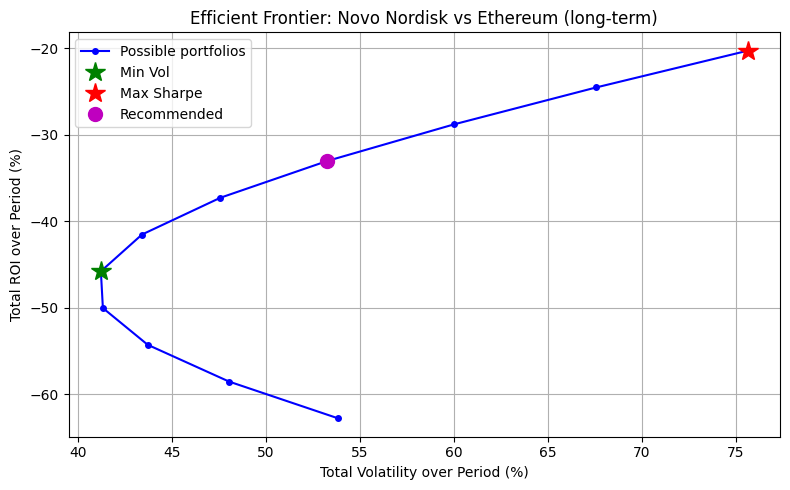

In [163]:
analyze_allocation_roi2(250_000, df_novo, df_eth, risk_profile='balanced', horizon='long-term')


--- Long-term horizon (full data) ---

Asset Characteristics (over the whole period):
Novo Nordisk: Total ROI = -62.78%, Total Volatility = 53.84%
Ethereum:     Total ROI = -20.27%, Total Volatility = 75.63%
Correlation: -0.1331

Pure Strategies (buy & hold over selected period):
Novo Nordisk:
  Buy at 2025-03-03: DKK  63,910.00
  Sell at 2026-02-27: DKK  23,790.00
  End value: DKK  93,060.55 | ROI: -62.78%
Ethereum:
  Buy at 2025-03-03: DKK  15,303.53
  Sell at 2026-02-27: DKK  12,201.79
  End value: DKK 199,329.66 | ROI: -20.27%

--- Portfolio Optimization ---
Minimum Volatility Portfolio:
  Novo: 60.0%, Ethereum: 40.0%
  Total ROI: -45.77%, Total Volatility: 41.21%
  Sharpe: -1.111

Maximum Sharpe (Tangency) Portfolio:
  Novo: 0.0%, Ethereum: 100.0%
  Total ROI: -20.27%, Total Volatility: 75.63%
  Sharpe: -0.268

Strategy type: Pure strategy

--- Recommendation based on 'aggressive' profile ---
Allocate:
  Novo Nordisk: 0.0% (DKK       0.00)
  Ethereum:     100.0% (DKK 250,000.00)


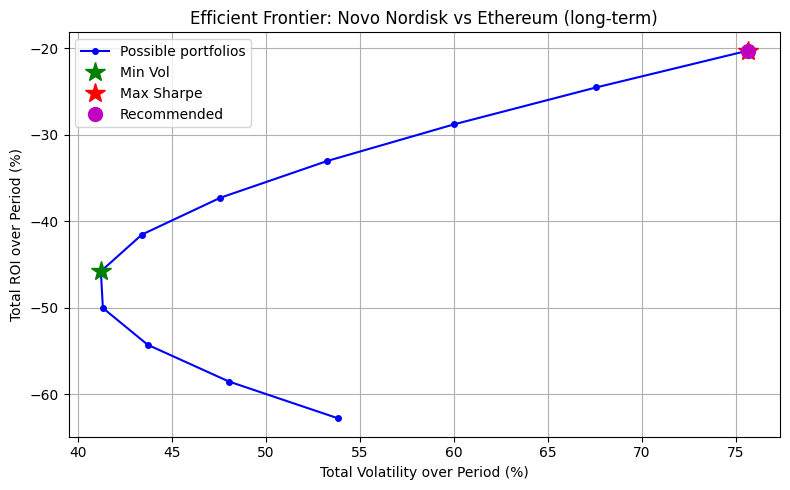

In [164]:
analyze_allocation_roi2(250_000, df_novo, df_eth, risk_profile='aggressive', horizon='long-term')


--- Long-term horizon (full data) ---

Asset Characteristics (over the whole period):
Novo Nordisk: Total ROI = -62.78%, Total Volatility = 53.84%
Ethereum:     Total ROI = -20.27%, Total Volatility = 75.63%
Correlation: -0.1331

Pure Strategies (buy & hold over selected period):
Novo Nordisk:
  Buy at 2025-03-03: DKK  63,910.00
  Sell at 2026-02-27: DKK  23,790.00
  End value: DKK  93,060.55 | ROI: -62.78%
Ethereum:
  Buy at 2025-03-03: DKK  15,303.53
  Sell at 2026-02-27: DKK  12,201.79
  End value: DKK 199,329.66 | ROI: -20.27%

--- Portfolio Optimization ---
Minimum Volatility Portfolio:
  Novo: 60.0%, Ethereum: 40.0%
  Total ROI: -45.77%, Total Volatility: 41.21%
  Sharpe: -1.111

Maximum Sharpe (Tangency) Portfolio:
  Novo: 0.0%, Ethereum: 100.0%
  Total ROI: -20.27%, Total Volatility: 75.63%
  Sharpe: -0.268

Strategy type: Hybrid strategy

--- Recommendation based on 'conservative' profile ---
Allocate:
  Novo Nordisk: 60.0% (DKK 150,000.00)
  Ethereum:     40.0% (DKK 100,000.

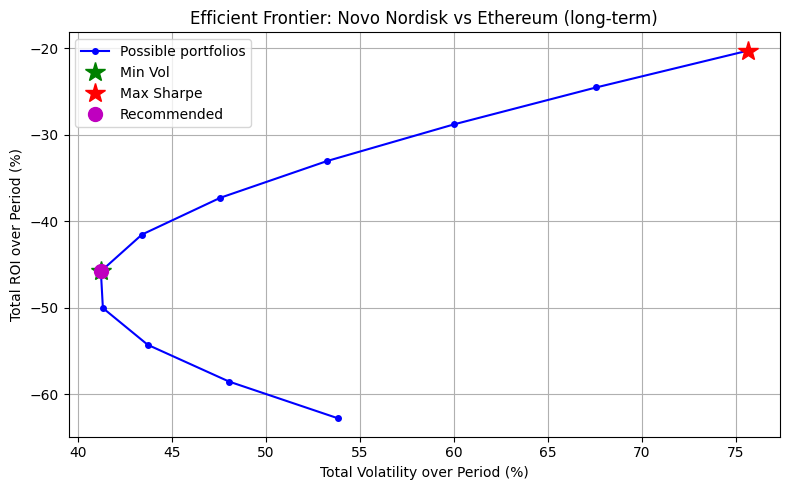

In [165]:
analyze_allocation_roi2(250_000, df_novo, df_eth, risk_profile='conservative', horizon='long-term')


--- Short-term horizon (last 4 months) ---

Asset Characteristics (over the whole period):
Novo Nordisk: Total ROI = -26.28%, Total Volatility = 10.62%
Ethereum:     Total ROI = -50.32%, Total Volatility = 54.79%
Correlation: -0.0765

Pure Strategies (buy & hold over selected period):
Novo Nordisk:
  Buy at 2025-10-30: DKK  32,270.00
  Sell at 2026-02-27: DKK  23,790.00
  End value: DKK 184,304.31 | ROI: -26.28%
Ethereum:
  Buy at 2025-10-30: DKK  24,562.24
  Sell at 2026-02-27: DKK  12,201.79
  End value: DKK 124,192.56 | ROI: -50.32%

--- Portfolio Optimization ---
Minimum Volatility Portfolio:
  Novo: 100.0%, Ethereum: 0.0%
  Total ROI: -26.28%, Total Volatility: 10.62%
  Sharpe: -2.474

Maximum Sharpe (Tangency) Portfolio:
  Novo: 0.0%, Ethereum: 100.0%
  Total ROI: -50.32%, Total Volatility: 54.79%
  Sharpe: -0.918

Strategy type: Hybrid strategy

--- Recommendation based on 'balanced' profile ---
Allocate:
  Novo Nordisk: 50.0% (DKK 125,000.00)
  Ethereum:     50.0% (DKK 125,000

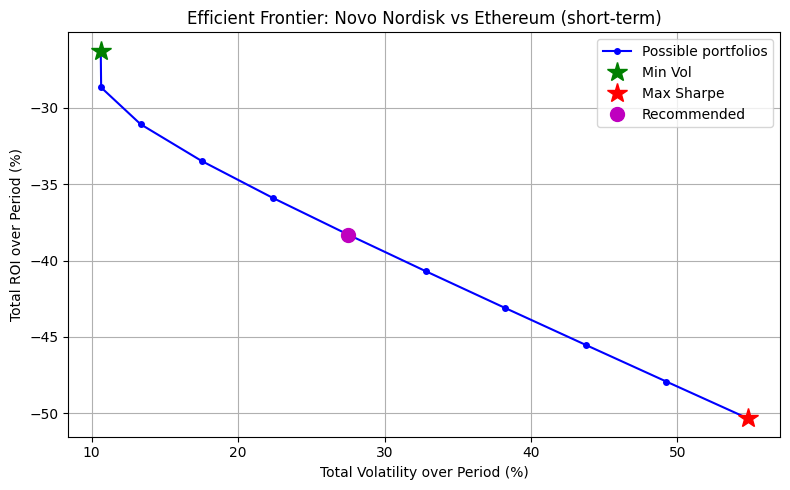

In [166]:
analyze_allocation_roi2(250_000, df_novo, df_eth, risk_profile='balanced', horizon='short-term')

| Strategy     | Allocation                      | ROI         | Volatility |
| ------------ | ------------------------------- | ----------- | ---------- |
| Conservative | 60% Novo / 40% Ethereum | **−45.77%** | **41.21%** |
| Balanced     | 30% Novo / 70% Ethereum         | **−33.02%** | **53.26%** |
| Aggressive   | 0% Novo / 100% Ethereum         | **−20.27%** | **75.63%** |


*   The combination of Ethereum and Novo Nordisk reduces risk, due to their slightly negative correlation (when one goes down, the other may go up).

*   The portfolio, which offers the minimum volatility would be a hybrid one: 60% to Novo Nordisk and 40% to Ethereum, which is the conservative strategy.

*   While a more agressive invester would prefer Ethereum alone, due to it having the higest ROI, it also comes with a very high volatility, which is not usually preferred in portfolios.

*   A hybric, but balanced strategy means more diversification and gives a more balanced trade-off between risk and return. The 30% Novo and 70% Ethereum portfolio

*   It is important to note, that both Ethereum and Novo Nordisk produced negative ROI in the given time-period. A longer-term horizen, with mode data would be preferred to make decisions.

# 3. **Market Timing and Seasonality**


*   3.1. Identify patterns using probabilistic models
*   3.2. Select the features for predictions
*   3.3. Apply models for predictions
*   3.4. Regularize the models & Choose the best one

Models trained for the predictions:
1. Logistics Regression
2. Random Forest
3. Decision Tree

####3.1. Identify patterns using probabilistic models
In the context of the investment decision, regime detection answers a very practical question: "Was the market calm or turbulent on any given day, and can we identify when it shifted?". Or in other words, it can help to detect when market is more volatile. In the previous section we mainly used EDA to eyball when the market is more volatile. In practice, this simply means:
- Entering during a low-volatility regime = more predictable returns, lower risk
- Entering during a high-volatility regime = higher risk, but also possible large gains
- Identifying regime shifts = potential early warning of a crash coming

Thus, we wil use a Gaussian Mixture Model (GMM) as a probabilistic model to determine the market regime with two options volatility: "low" and "high".

The GMM is preferred over K-Means for market regime detection for several reasons.
- Unlike K-Means, which assigns each day to either a low- or high-volatility regime, GMM produces a soft probability for each observation. For example, there could be days which are 75% likely to belong to the high-volatility regime and 25% to the low-volatility one. This is more realistic in financial markets, where regime transitions are gradual rather than abrupt.
- Furthermore, K-Means assumes clusters of equal, spherical shape, which is an unrealistic constraint for financial return distributions that naturally exhibit different variances across regimes. GMM relaxes this assumption by allowing each component to have its own mean and covariance structure, making it better suited to capture the asymmetric and heterogeneous nature of market behaviour.
- Finally, the probabilistic output of GMM is directly reusable as a feature in subsequent supervised learning models (which will be used for predictions), where the estimated probability of being in a low/high regimes is as a meaningful predictor of future returns.

In [167]:

# 1. Prepare the feature
# We use 10-day rolling volatility as our input to the GMM because it smooths out day-to-day noise
# conver to log are much closer to stationary and normally distributed
# log return measures the daily percentage change in price)

# convert date column to datetime and set as index ───────────────
df_eth['date']  = pd.to_datetime(df_eth['date'])
df_novo['date'] = pd.to_datetime(df_novo['date'])

df_eth  = df_eth.set_index('date')
df_novo = df_novo.set_index('date')

#21 trading days = approximately 1 calendar month. This is the standard window used in academic finance research for monthly volatility estimation.
eth_vol  = df_eth['log_ret'].rolling(21).std().dropna()
novo_vol = df_novo['log_ret'].rolling(21).std().dropna()

# 2. Fit the GMM
# n_components=2 means we want exactly 2 regimes (low-vol and high-vol). We want GMM to find 2 regimes

gmm_eth  = GaussianMixture(n_components=2, random_state=42)
gmm_novo = GaussianMixture(n_components=2, random_state=42)

gmm_eth.fit(eth_vol.values.reshape(-1, 1))
gmm_novo.fit(novo_vol.values.reshape(-1, 1))

# 3. Label each day as low-vol (0) or high-vol (1
# predict() gives a hard label: 0 or 1

eth_labels  = gmm_eth.predict(eth_vol.values.reshape(-1, 1))
novo_labels = gmm_novo.predict(novo_vol.values.reshape(-1, 1))

# the component with the higher mean volatility = high-vol regime
# argmax finds the index (0 or 1) of the larger mean
eth_highvol_idx  = np.argmax(gmm_eth.means_)
novo_highvol_idx = np.argmax(gmm_novo.means_)

# Remap so that 1 always means high-vol, 0 always means low-vol
eth_regime  = (eth_labels  == eth_highvol_idx).astype(int)
novo_regime = (novo_labels == novo_highvol_idx).astype(int)

# 4. Get soft probabilities
# predict_proba() gives the probability of belonging to each component

eth_prob_highvol  = gmm_eth.predict_proba(
    eth_vol.values.reshape(-1, 1))[:, eth_highvol_idx]

novo_prob_highvol = gmm_novo.predict_proba(
    novo_vol.values.reshape(-1, 1))[:, novo_highvol_idx]

/tmp/ipykernel_1915/3199608649.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eth['date']  = pd.to_datetime(df_eth['date'])


In [168]:
for name, vol, regime in [("Ethereum",     eth_vol,  eth_regime),
                           ("Novo Nordisk", novo_vol, novo_regime)]:
    n_highvol = regime.sum()
    n_lowvol  = len(regime) - n_highvol
    print(f"\n{name}")
    print(f"  Low-volatility days  : {n_lowvol}  ({n_lowvol/len(regime)*100:.1f}%)")
    print(f"  High-volatility days : {n_highvol} ({n_highvol/len(regime)*100:.1f}%)")


Ethereum
  Low-volatility days  : 250  (72.5%)
  High-volatility days : 95 (27.5%)

Novo Nordisk
  Low-volatility days  : 190  (83.0%)
  High-volatility days : 39 (17.0%)


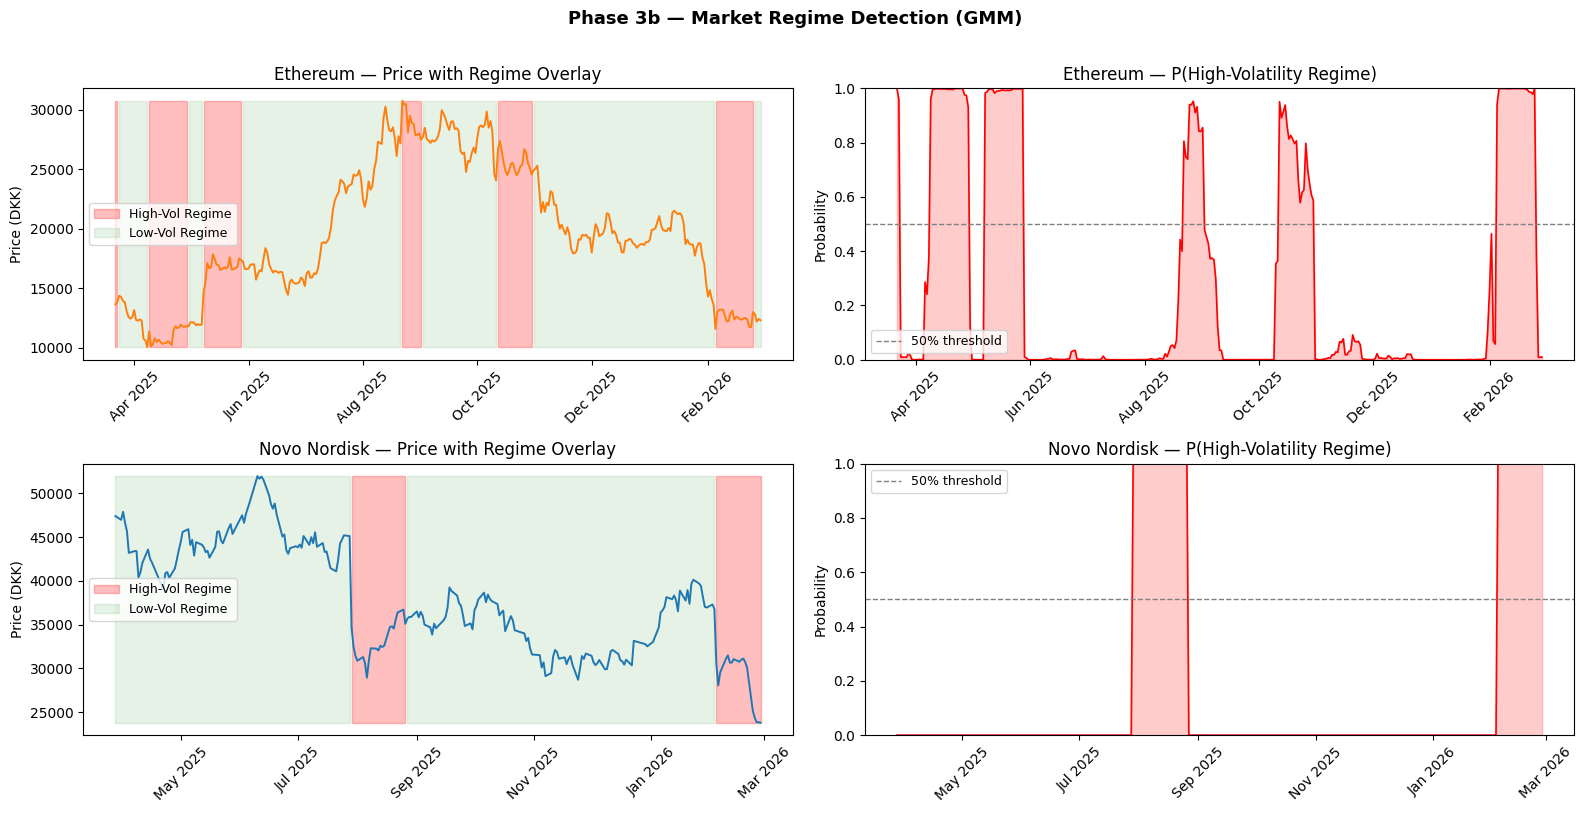

In [169]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for i, (name, prices, vol, regime, prob, color) in enumerate([
    ("Ethereum",     df_eth['close'],  eth_vol,  eth_regime,  eth_prob_highvol,  ETH_COL),
    ("Novo Nordisk", df_novo['close'], novo_vol, novo_regime, novo_prob_highvol, NOVO_COL),
]):
    # --- Left panel: Price chart with regime shading ---
    ax = axes[i, 0]
    price_aligned = prices.loc[vol.index]

    ax.plot(price_aligned.index, price_aligned, color=color, lw=1.4)
    ax.fill_between(vol.index,
                    price_aligned.min(), price_aligned.max(),
                    where=(regime == 1),
                    alpha=0.25, color='red',   label='High-Vol Regime')
    ax.fill_between(vol.index,
                    price_aligned.min(), price_aligned.max(),
                    where=(regime == 0),
                    alpha=0.10, color='green', label='Low-Vol Regime')
    ax.set_title(f'{name} — Price with Regime Overlay')
    ax.set_ylabel('Price (DKK)')
    ax.legend(fontsize=9)

    # ── Format x-axis as dates ─────────────────────────────────────
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=45)

    # --- Right panel: Probability of high-vol regime ---
    ax = axes[i, 1]
    ax.plot(vol.index, prob, color='red', lw=1.2)
    ax.fill_between(vol.index, prob, alpha=0.2, color='red')
    ax.axhline(0.5, color='grey', lw=1, ls='--', label='50% threshold')
    ax.set_title(f'{name} — P(High-Volatility Regime)')
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)

    # ── Format x-axis as dates ─────────────────────────────────────
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Phase 3b — Market Regime Detection (GMM)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Ethereum:**
identified 5 distinct high-volatility periods:
Early period: ETH was crashing from ~13,000 down to ~10,000 DKK — correctly flagged as high-vol
Mid period: The peak around 30,000 DKK followed by a sharp decline — correctly flagged
Later periods: The continued decline toward 12,000 DKK — correctly flagged

**Novo Nordisk** (partially good)
two high-vol periods:

between Jul-Sept 2025: The sharp crash from 45,000 → 28,000 DKK — correctly  
between Feb-March 2026: The final decline toward 24,000 DKK — correctly flagged

However there is one clear limitation — the early sustained decline from ~47,000 down to ~35,000 DKK (roughly first few months) is classified entirely as low-volatility. This is the main weakness of the result. This happens because Novo's early decline was gradual and steady — volatility was actually relatively low even though the price was falling. The GMM detects turbulence (large daily swings), not direction (trending downward).

#### 3.2. Select the features for predictions

In [170]:
#convert this to dummy variable
df_eth['anomaly']  = (df_eth['anomaly']  == -1).astype(int)
df_novo['anomaly'] = (df_novo['anomaly'] == -1).astype(int)

def build_features(df, prob_highvol, asset_name):
    """
    df           : full dataframe (df_eth or df_novo) with date as index
    prob_highvol : GMM probability series from Phase 3b
    asset_name   : label for printing
    """

    feat = pd.DataFrame(index=df.index)

    # ── Feature 1: Lagged log returns ─────────────────────────────────────
    feat['ret_lag1'] = df['log_ret'].shift(1)
    feat['ret_lag2'] = df['log_ret'].shift(2)
    feat['ret_lag5'] = df['log_ret'].shift(5)

    # ── Feature 2: Rolling volatility ─────────────────────────────────────
    feat['rolling_vol_5']  = df['log_ret'].shift(1).rolling(5).std()
    feat['rolling_vol_10'] = df['log_ret'].shift(1).rolling(10).std()

    # ── Feature 3: Rolling mean return ────────────────────────────────────
    feat['rolling_mean_5']  = df['log_ret'].shift(1).rolling(5).mean()
    feat['rolling_mean_20'] = df['log_ret'].shift(1).rolling(20).mean()

    # ── Feature 4: Anomaly flag (from Phase 3c) ───────────────────────────
    feat['anomaly'] = df['anomaly'].shift(1)

    # ── Feature 5: GMM regime probability (from Phase 3b) ─────────────────
    feat['prob_highvol'] = prob_highvol.reindex(df.index)

    # ── Feature 6: Month of year ───────────────────────────────────────────
    feat['month'] = df.index.month

    # Drop rows with NaN
    feat = feat.dropna()

    return feat


X_eth  = build_features(df_eth,
                         pd.Series(eth_prob_highvol, index=eth_vol.index),
                         'Ethereum')

X_novo = build_features(df_novo,
                         pd.Series(novo_prob_highvol, index=novo_vol.index),
                         'Novo Nordisk')

print("\nETH feature table shape  :", X_eth.shape)
print("Novo feature table shape :", X_novo.shape)
print("\nFeature columns:", X_eth.columns.tolist())


ETH feature table shape  : (345, 10)
Novo feature table shape : (229, 10)

Feature columns: ['ret_lag1', 'ret_lag2', 'ret_lag5', 'rolling_vol_5', 'rolling_vol_10', 'rolling_mean_5', 'rolling_mean_20', 'anomaly', 'prob_highvol', 'month']


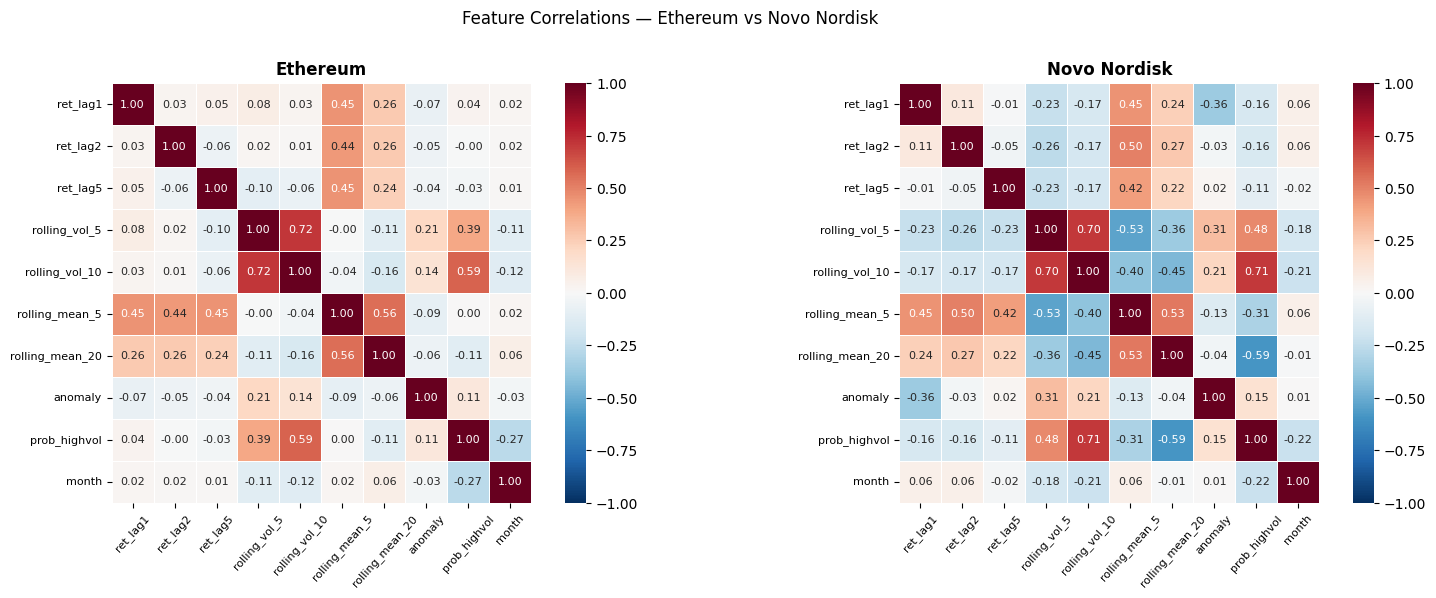

In [171]:
#plot correlation heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, X, title in zip(axes,
                         [X_eth,        X_novo],
                         ['Ethereum',   'Novo Nordisk']):
    corr = X.corr()
    sns.heatmap(corr,ax   = ax, annot= True, fmt  = '.2f', cmap = 'RdBu_r', center= 0, vmin = -1, vmax = 1, square= True, linewidths = 0.5, annot_kws= {'size': 8}
    )

    ax.set_title(f'{title}',
                 fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=48, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Feature Correlations — Ethereum vs Novo Nordisk\n',
             fontsize=12)
plt.tight_layout()
plt.show()

As we can see from the graph above, we have some features which are strongly correlated. For example, there is a noticable correlation between rolling volatilities with different duration, probability of high volatility season with the rolling volatility, and different return mean periods. Hence, the correlation between variables should be considered when selecting a model for return prediction.

#### 3.3. Apply models for predictions

Train the models to predict the direction of the returns: wether it will be up or down (binary prediction)

In [172]:
# STEP 1 — Build targets for each horizon
# For each horizon we ask: "will the price be higher in N days?"
# 1 = price goes UP,  0 = price goes DOWN

def build_target(df, X, horizon, label):
    """
    X       : feature table
    horizon : number of days to look ahead (1, 5, or 21)
    """
    # Sum of next N log returns = total return over the horizon
    future_return = df['log_ret'].shift(-horizon)

    # 1 if positive return, 0 if negative
    y = (future_return > 0).astype(int)

    # Align with feature table and drop NaN
    y = y.reindex(X.index).dropna()

    print(f"  {label}: {y.sum()} up days / {(y==0).sum()} down days "
          f"({y.mean()*100:.1f}% up)")
    return y

# X_eth and X_novo were built by build_features()
# We need to make sure they only contain dates that exist in both the feature table and the target variable

X_eth_aligned  = X_eth.dropna()
X_novo_aligned = X_novo.dropna()

#### <font color='blue'> Logistics Regression + L1 / L2 penalty <font>

---
Logistic Regression with L2 penalty was selected as the baseline model.
It is the simplest interpretable classifier, thus it is good starting point before applying more complex models. Also, L2 penalty was chosen over L1 because it shrinks all feature coefficients proportionally rather than eliminating them entirely. Since we do not have a lot of domain knowledge we prefer including more features rather than selecting them aggresively beforhand. Additionally, L2 is less sensitive to correlated features. This is very relevant because features like rolling volatility, lagged returns and regime probability are correlated with each other.


In [173]:
# STEP 1 — Build targets for each horizon
# For each horizon we ask: "will the price be higher in N days?"
# 1 = price goes UP,  0 = price goes DOWN

def build_target(df, X, horizon, label):
    """
    X       : feature table
    horizon : number of days to look ahead (1, 5, or 21)
    """
    # Sum of next N log returns = total return over the horizon
    future_return = df['log_ret'].shift(-horizon)

    # 1 if positive return, 0 if negative
    y = (future_return > 0).astype(int)

    # Align with feature table and drop NaN
    y = y.reindex(X.index).dropna()

    print(f"  {label}: {y.sum()} up days / {(y==0).sum()} down days "
          f"({y.mean()*100:.1f}% up)")
    return y

# X_eth and X_novo were built by build_features()
# We need to make sure they only contain dates that exist in both the feature table and the target variable

X_eth_aligned  = X_eth.dropna()
X_novo_aligned = X_novo.dropna()

print("=== ETH Targets ===")
y_eth_day   = build_target(df_eth, X_eth_aligned, horizon=1,  label="Next-Day")
y_eth_week  = build_target(df_eth, X_eth_aligned, horizon=5,  label="Next-Week")
y_eth_month = build_target(df_eth, X_eth_aligned, horizon=21, label="Next-Month")

print("\n=== Novo Targets ===")
y_novo_day   = build_target(df_novo, X_novo_aligned, horizon=1,  label="Next-Day")
y_novo_week  = build_target(df_novo, X_novo_aligned, horizon=5,  label="Next-Week")
y_novo_month = build_target(df_novo, X_novo_aligned, horizon=21, label="Next-Month")

=== ETH Targets ===
  Next-Day: 170 up days / 175 down days (49.3% up)
  Next-Week: 168 up days / 177 down days (48.7% up)
  Next-Month: 163 up days / 182 down days (47.2% up)

=== Novo Targets ===
  Next-Day: 107 up days / 122 down days (46.7% up)
  Next-Week: 106 up days / 123 down days (46.3% up)
  Next-Month: 97 up days / 132 down days (42.4% up)



═══════════════════════════════════════════════════════
Ethereum
═══════════════════════════════════════════════════════

  Ethereum | Next-Day | Penalty = L1
    Best C       : 100.0
    CV AUC       : 0.5438  ← chosen by grid search
    Test Accuracy: 0.4783
    Test F1      : 0.5263
    Test AUC-ROC : 0.5068

  Ethereum | Next-Day | Penalty = L2
    Best C       : 100.0
    CV AUC       : 0.5450  ← chosen by grid search
    Test Accuracy: 0.4783
    Test F1      : 0.5263
    Test AUC-ROC : 0.5060

  Ethereum | Next-Week | Penalty = L1
    Best C       : 0.001
    CV AUC       : 0.5000  ← chosen by grid search
    Test Accuracy: 0.5942
    Test F1      : 0.0000
    Test AUC-ROC : 0.5000

  Ethereum | Next-Week | Penalty = L2
    Best C       : 100.0
    CV AUC       : 0.4732  ← chosen by grid search
    Test Accuracy: 0.4348
    Test F1      : 0.5301
    Test AUC-ROC : 0.3815

  Ethereum | Next-Month | Penalty = L1
    Best C       : 0.001
    CV AUC       : 0.5000  ← chosen by grid

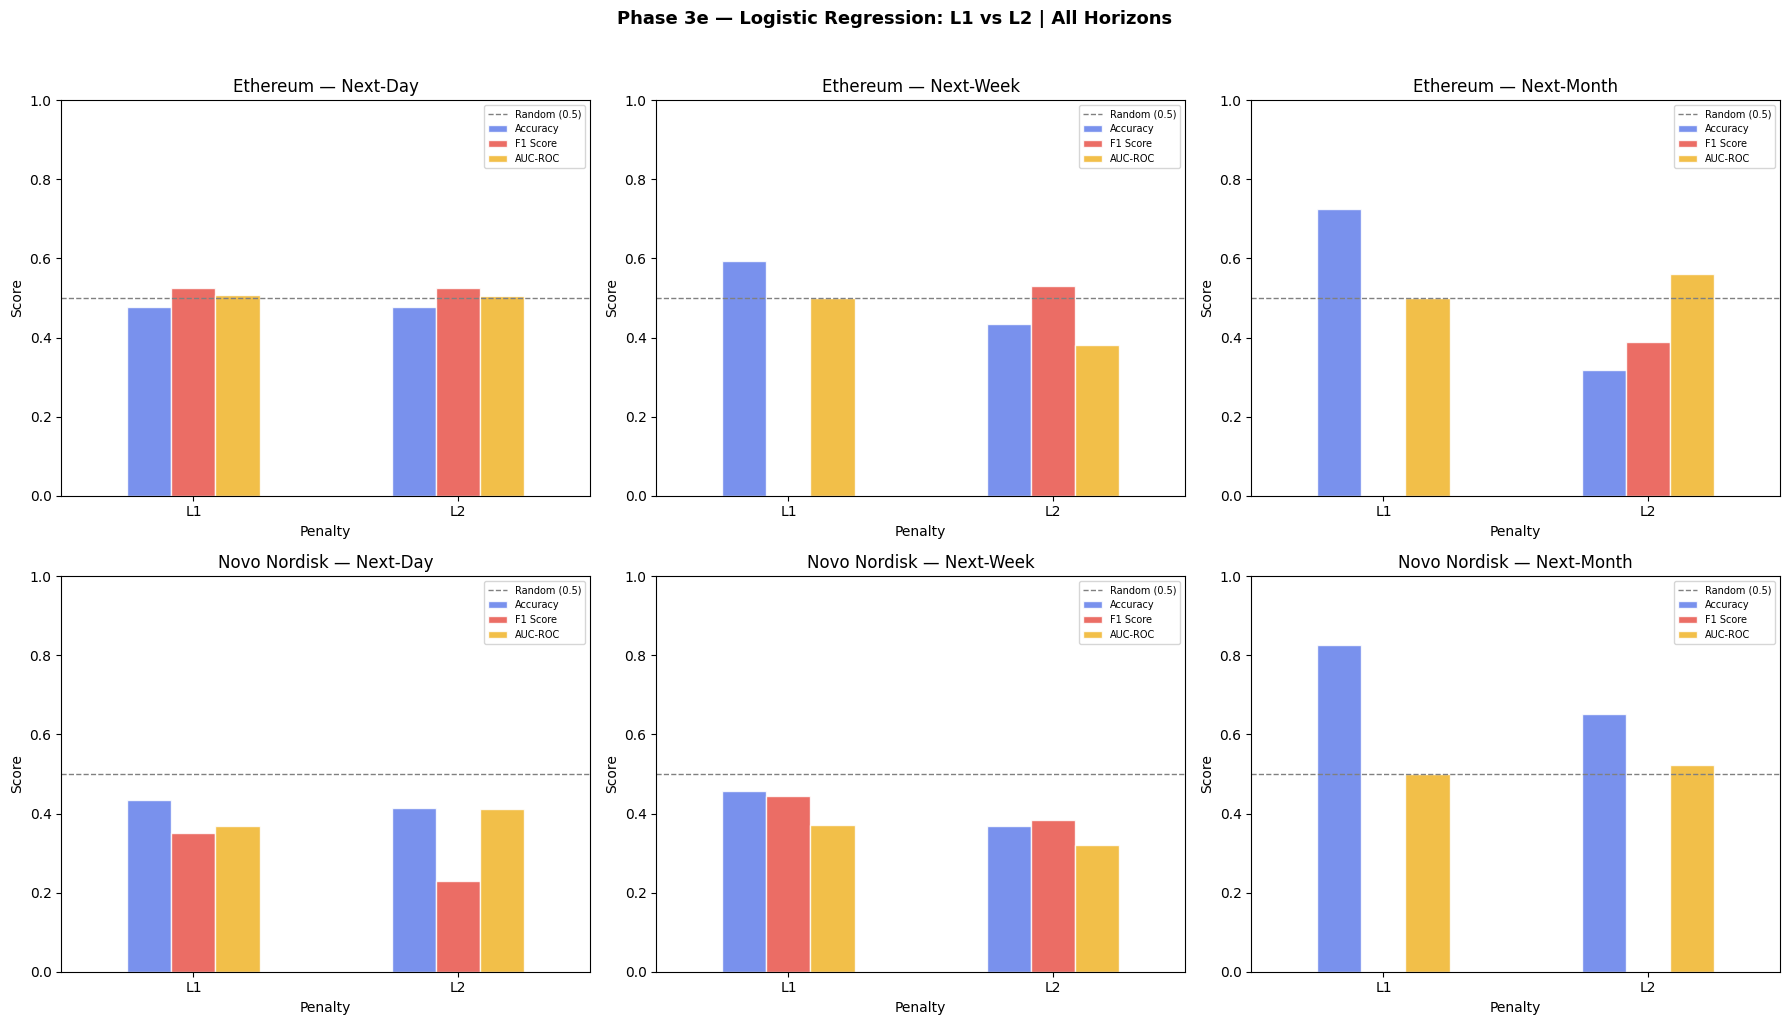

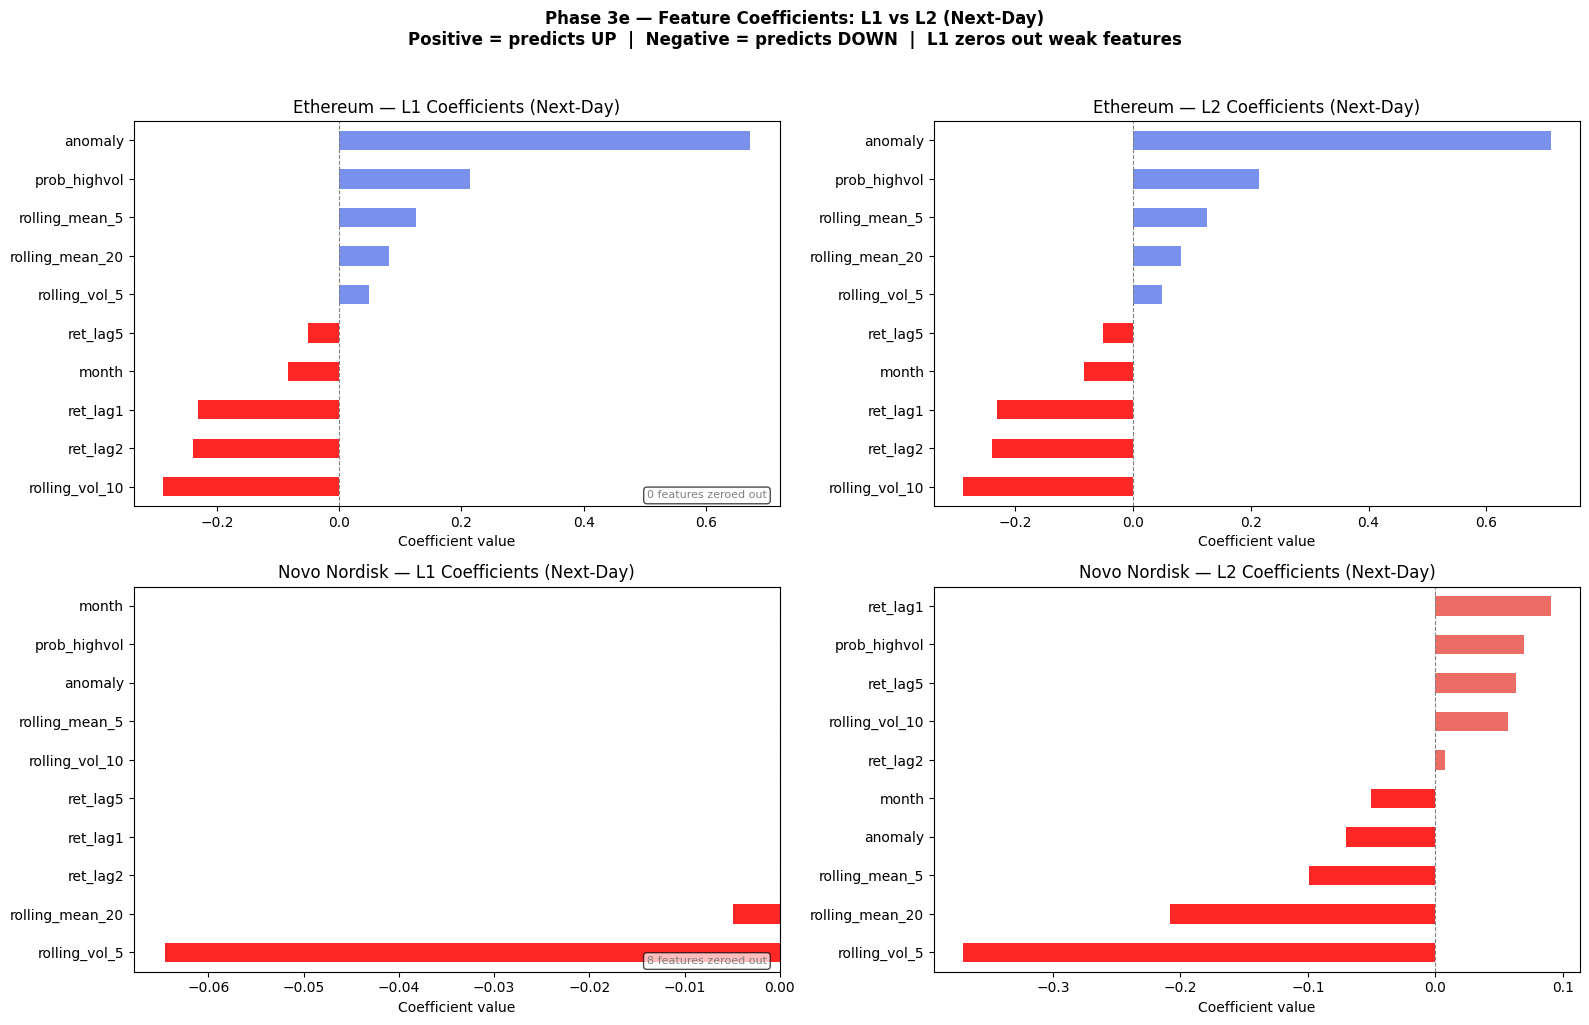

In [175]:
# ═══════════════════════════════════════════════════════════════════════════
# STEP 1 — Define Grid Search parameters
# ═══════════════════════════════════════════════════════════════════════════
# C controls regularisation strength:
#   small C (e.g. 0.01) = strong regularisation = simpler model
#   large C (e.g. 100)  = weak regularisation  = more complex model

param_grid_l1 = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

param_grid_l2 = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

# ═══════════════════════════════════════════════════════════════════════════
# STEP 2 — Time series cross-validation
# ═══════════════════════════════════════════════════════════════════════════
# TimeSeriesSplit creates multiple train/test folds
# always keeping chronological order
# n_splits=5 means 5 rounds of training/testing

tscv = TimeSeriesSplit(n_splits=5)

# ═══════════════════════════════════════════════════════════════════════════
# STEP 3 — Main function: Grid Search + Evaluate
# ═══════════════════════════════════════════════════════════════════════════

def run_gridsearch_logistic(X, y, horizon_label, asset_name):
    """
    Runs Grid Search separately for L1 and L2 penalty.
    Returns results for both penalties.
    """

    # Align X and y
    X_aligned = X.loc[y.index]

    # ── Time split ─────────────────────────────────────────────────────────
    split    = int(len(X_aligned) * 0.8)
    X_train  = X_aligned.iloc[:split]
    X_test   = X_aligned.iloc[split:]
    y_train  = y.iloc[:split]
    y_test   = y.iloc[split:]

    # ── Scale ──────────────────────────────────────────────────────────────
    scaler      = StandardScaler()
    X_train_sc  = scaler.fit_transform(X_train)
    X_test_sc   = scaler.transform(X_test)

    results = []

    for penalty, param_grid in [('l1', param_grid_l1), ('l2', param_grid_l2)]:

        # Choose solver based on penalty
        # liblinear supports both L1 and L2
        # lbfgs only supports L2
        solver = 'liblinear'

        # ── Grid Search ────────────────────────────────────────────────────
        # scoring='roc_auc' means we optimise for AUC-ROC
        # cv=tscv uses time-series cross validation (no random splits)
        grid = GridSearchCV(
            estimator  = LogisticRegression(
                            penalty=penalty,
                            solver=solver,
                            random_state=42,
                            max_iter=1000),
            param_grid = param_grid,
            cv         = tscv,
            scoring    = 'roc_auc',
            n_jobs     = -1            # use all CPU cores
        )
        grid.fit(X_train_sc, y_train)

        # ── Best model ─────────────────────────────────────────────────────
        best_model = grid.best_estimator_
        best_C     = grid.best_params_['C']
        best_cv_auc = grid.best_score_

        # ── Evaluate on test set ───────────────────────────────────────────
        y_pred  = best_model.predict(X_test_sc)
        y_proba = best_model.predict_proba(X_test_sc)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred, zero_division=0)
        auc = roc_auc_score(y_test, y_proba)

        results.append({
            'Asset':       asset_name,
            'Horizon':     horizon_label,
            'Penalty':     penalty.upper(),
            'Best C':      best_C,
            'CV AUC':      round(best_cv_auc, 4),
            'Accuracy':    round(acc, 4),
            'F1 Score':    round(f1,  4),
            'AUC-ROC':     round(auc, 4),
            'model':       best_model,
            'X_test_sc':   X_test_sc,
            'y_test':      y_test,
            'features':    X.columns.tolist(),
        })

        print(f"\n  {asset_name} | {horizon_label} | Penalty = {penalty.upper()}")
        print(f"    Best C       : {best_C}")
        print(f"    CV AUC       : {best_cv_auc:.4f}  ← chosen by grid search")
        print(f"    Test Accuracy: {acc:.4f}")
        print(f"    Test F1      : {f1:.4f}")
        print(f"    Test AUC-ROC : {auc:.4f}")

    return results

# ═══════════════════════════════════════════════════════════════════════════
# STEP 4 — Run for all horizons and both assets
# ═══════════════════════════════════════════════════════════════════════════

all_results = []

for asset, X, target_list in [
    ("Ethereum",     X_eth_aligned,
     [("Next-Day",   y_eth_day),
      ("Next-Week",  y_eth_week),
      ("Next-Month", y_eth_month)]),

    ("Novo Nordisk", X_novo_aligned,
     [("Next-Day",   y_novo_day),
      ("Next-Week",  y_novo_week),
      ("Next-Month", y_novo_month)]),
]:
    print("\n" + "═"*55)
    print(f"{asset}")
    print("═"*55)

    for horizon_label, y in target_list:
        res = run_gridsearch_logistic(X, y, horizon_label, asset)
        all_results.extend(res)

# ═══════════════════════════════════════════════════════════════════════════
# STEP 5 — Clean summary table
# ═══════════════════════════════════════════════════════════════════════════

summary = pd.DataFrame([
    {k: v for k, v in r.items()
     if k not in ['model', 'X_test_sc', 'y_test', 'features']}
    for r in all_results
])

# ── Print L1 and L2 separately ─────────────────────────────────────────────
print("\n" + "═"*65)
print("RESULTS — L1 Penalty (Lasso: drives weak features to zero)")
print("═"*65)
print(summary[summary['Penalty'] == 'L1'].to_string(index=False))

print("\n" + "═"*65)
print("RESULTS — L2 Penalty (Ridge: shrinks all features evenly)")
print("═"*65)
print(summary[summary['Penalty'] == 'L2'].to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════
# STEP 6 — Plot: L1 vs L2 comparison per asset and horizon
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

horizons = ["Next-Day", "Next-Week", "Next-Month"]

for row, asset in enumerate(["Ethereum", "Novo Nordisk"]):
    for col, horizon in enumerate(horizons):

        ax = axes[row, col]

        # Filter for this asset and horizon
        subset = summary[
            (summary['Asset']   == asset) &
            (summary['Horizon'] == horizon)
        ].set_index('Penalty')

        subset[['Accuracy', 'F1 Score', 'AUC-ROC']].plot(
            kind='bar', ax=ax, width=0.5,
            color=['#627EEA', '#E8534A', '#F0B429'],
            alpha=0.85, edgecolor='white'
        )

        ax.axhline(0.5, color='grey', lw=1, ls='--', label='Random (0.5)')
        ax.set_title(f'{asset} — {horizon}')
        ax.set_ylabel('Score')
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=0)
        ax.legend(fontsize=7)

plt.suptitle('Phase 3e — Logistic Regression: L1 vs L2 | All Horizons',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# STEP 7 — Feature coefficients: L1 vs L2 side by side
# ═══════════════════════════════════════════════════════════════════════════
# L1 will drive some coefficients to exactly 0 (feature selection)
# L2 will shrink all coefficients but keep them all non-zero

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Show coefficients for Next-Day horizon only (clearest comparison)
for row, asset in enumerate(["Ethereum", "Novo Nordisk"]):
    for col, penalty in enumerate(["L1", "L2"]):

        ax  = axes[row, col]
        res = next(r for r in all_results
                   if r['Asset']   == asset
                   and r['Horizon'] == 'Next-Day'
                   and r['Penalty'] == penalty)

        coef   = pd.Series(res['model'].coef_[0], index=res['features'])
        coef   = coef.sort_values()
        colors = ['red' if c < 0 else '#627EEA' if asset == 'Ethereum'
                  else '#E8534A' for c in coef]

        coef.plot(kind='barh', ax=ax, color=colors, alpha=0.85)
        ax.axvline(0, color='grey', lw=0.8, ls='--')
        ax.set_title(f'{asset} — {penalty} Coefficients (Next-Day)')
        ax.set_xlabel('Coefficient value')

        # Highlight zeroed-out features (L1 only)
        if penalty == 'L1':
            zeroed = (coef == 0).sum()
            ax.text(0.98, 0.02, f'{zeroed} features zeroed out',
                    transform=ax.transAxes, ha='right', fontsize=8,
                    color='grey',
                    bbox=dict(boxstyle='round', fc='white', alpha=0.7))

plt.suptitle('Phase 3e — Feature Coefficients: L1 vs L2 (Next-Day)\n'
             'Positive = predicts UP  |  Negative = predicts DOWN  |'
             '  L1 zeros out weak features',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The best result across all scenarios was Ethereum next-month AUC = 0.56. To put that in perspective:
- AUC of 0.50 = flipping a coin
- AUC of 0.56 = correctly ranking an up day above a down day 56% of the time
- AUC of 0.70+ = generally considered the minimum threshold for a useful model in practice

**Shoer Term: **The results reveal limited but horizon-dependent predictive performance. At the next-day and next-week horizons, both Ethereum and Novo Nordisk produce AUC scores near or below 0.5, indicating that the model performs no better than random guessing at short time periods.

**Long Term:** For the longer term (next-month), performance improves modestly — Ethereum reaches an AUC of 0.56, suggesting that volatility regime features carry some longer-term predictive information, while Novo Nordisk achieves an AUC of only 0.51.

Overall, the **model is insufficient for long-term investment decisions.** , This analysis shows that short-term returns are largely unpredictable, validating the relevance of volatility regime features over longer horizons. Any real investment recommendation should NOT BE be supported by this simplistic modeling. Thus, the predictive modeling with Logistics Regression L2 penalty is not a good model for financial short-term advices.

#### <font color='blue'> Random Forest <font>


---



TO DO

#### <font color='blue'> Decision Tree <font>

---

In [176]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [177]:
param_grid_dt = {
    "max_depth":         [2, 3, 5, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "criterion":         ["gini", "entropy"],
    "class_weight":      [None, "balanced"]
}

In [219]:
def run_gridsearch_dt(X, y, horizon_label, asset_name):
    X_aligned = X.loc[y.index] # ensures every row in X has a matching row in y

    # train/test split (80/20)
    split = int(len(X_aligned) * 0.8)
    X_train = X_aligned.iloc[:split]
    X_test  = X_aligned.iloc[split:]
    y_train = y.iloc[:split]
    y_test  = y.iloc[split:]

    # scale features
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # time series cross-validation
    tscv = TimeSeriesSplit(n_splits=5)

    # grid search
    dt = DecisionTreeClassifier(random_state=42)
    gs = GridSearchCV(dt, param_grid_dt, cv=tscv,
                      scoring="roc_auc", n_jobs=-1)
    gs.fit(X_train_sc, y_train)

    # evaluate best model on test set
    best_model = gs.best_estimator_
    y_pred  = best_model.predict(X_test_sc)
    y_proba = best_model.predict_proba(X_test_sc)[:, 1]

    return {
        "Asset":       asset_name,
        "Horizon":     horizon_label,
        "Best Params": gs.best_params_,
        "CV AUC":      round(gs.best_score_, 3),
        "Accuracy":    round(accuracy_score(y_test, y_pred), 3),
        "AUC":         round(roc_auc_score(y_test, y_proba), 3),
        "F1":          round(f1_score(y_test, y_pred), 3),
        "Model":       best_model,
        "Scaler":      scaler,
        "X_test":      X_test_sc,
        "y_test":      y_test,
    }

In [243]:
def display_dt_summary(dt_results, asset_name):
    asset_results = [r for r in dt_results if r["Asset"] == asset_name]

    rows = {}
    for r in asset_results:
        h = r["Horizon"]
        rows[h] = {
            "Best Depth":     r["Best Params"]["max_depth"],
            "Best Criterion": r["Best Params"]["criterion"],
            "Class Weight":   r["Best Params"]["class_weight"],
            "CV AUC":         r["CV AUC"],
            "Test Accuracy":  r["Accuracy"],
            "Test AUC":       r["AUC-ROC"],   # ← fixed
            "Test F1":        r["F1 Score"],  # ← fixed
        }

    df_summary = pd.DataFrame(rows).T
    print(f"\n{'='*90}")
    print(f"  Decision Tree Results — {asset_name}")
    print(f"{'='*90}")
    print(df_summary.to_string())


In [242]:
display_dt_summary(dt_results, "Ethereum")
display_dt_summary(dt_results, "Novo Nordisk")


                   Decision Tree Results — Ethereum                   
           Best Depth Best Criterion Class Weight  CV AUC Test Accuracy Test AUC Test F1
Next-Day            3           gini         None  0.5122        0.5507   0.5389  0.5079
Next-Week          10           gini     balanced  0.5275        0.5507   0.5592  0.5079
Next-Month         10           gini     balanced  0.5443        0.5507   0.5079  0.3922

                   Decision Tree Results — Novo Nordisk                   
           Best Depth Best Criterion Class Weight  CV AUC Test Accuracy Test AUC Test F1
Next-Day            2        entropy         None  0.5045         0.413   0.4058  0.1818
Next-Week          10        entropy         None  0.5909        0.5652   0.5721  0.5652
Next-Month       None           gini     balanced  0.5003        0.4783   0.4868    0.25


The decision tree results confirm that the short term proce direcetion is largely unpredectable for both assets. For example, the AUC for both assets for next day ranges is 0.5389 for Eth and 0.4058 for Novo Nordisk, which is barely ramdom (0.5), this show a weak form efficient market hypothesis, which suggests that past price patterns alone cannot realiably generate excess profits

At the next-day horizon, both assets perform near or below random: Eth achieves AUC of 0.54 and Novo Nordisk only 0.41. The Novo Nordisk next day result falling below 0.5 suggests the model overfit to noise in training data, further highlighting how short-term stock moves are driven by unpredictable events rather than historical price patterns

The next-week horizon produces the strongest signal for both assets, Novo Nordisk (AUC = 0.572) and Ethereum (AUC = 0.559). THis suggests a weak but consistent weekly cyclical patterns exist.
At the next-month horizon, predictability collapses again for both assets, which may reflect that longer term prices are increasingly driven by macroeconomic factors not captured in our technical features.

Overall, no horizon produces an AUC above 0.60. The Decision Tree should therefore be treated as a weak directional signal rather than a reliable trading rule.

